# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



Columns in the dataset: Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department',
       'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation'],
      dtype='object')
   HoursWorked  FocusScore  ProductivityScore   Department  YearsAtCompany  \
0         42.4         6.3            3127.96  Engineering              17   
1         34.0         7.2            4742.60           HR               8   
2         47.2         5.6            2044.73        Sales              15   
3         38.4         9.0            5818.92           HR               5   
4         36.4         2.5            1841.31        Sales               9   

   TeamMeetingsPerWeek    DeskLocation  
0                    0       Open Plan  
1                    6  Private Office  
2                    3          Remote  
3                    6  Private Office  
4                    6          Remote  


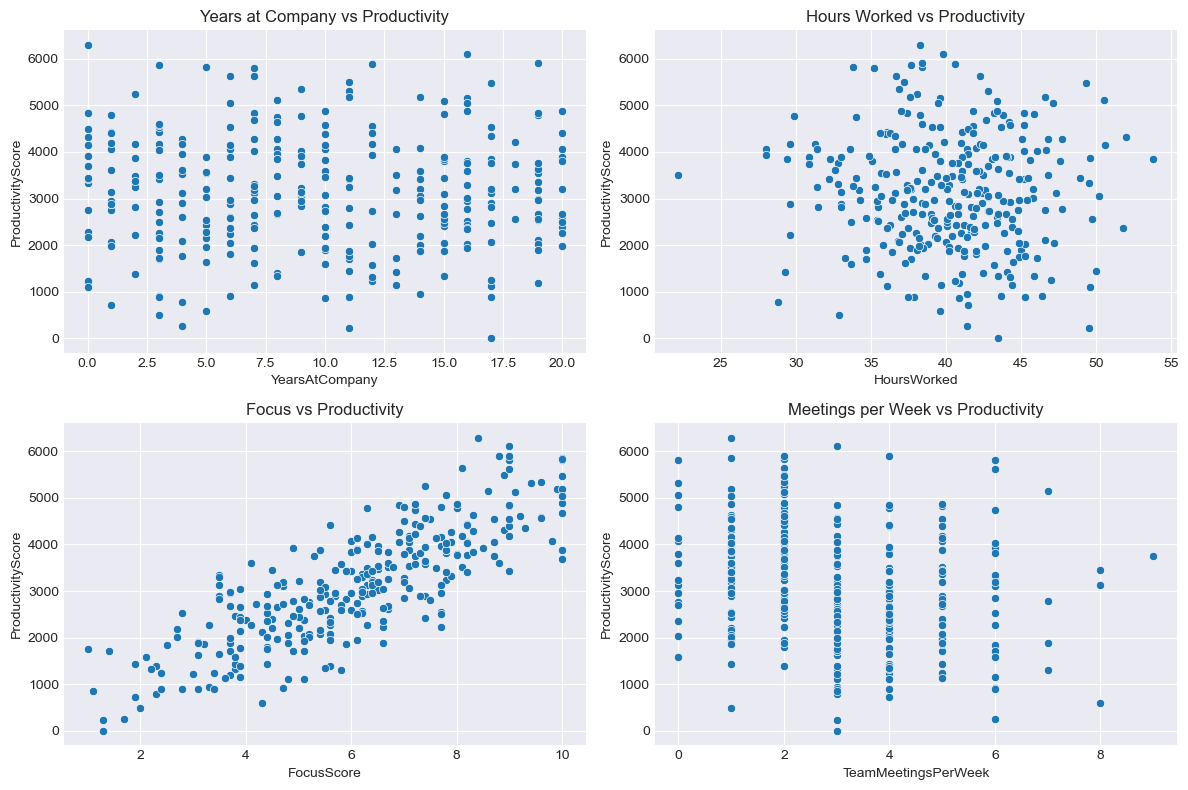

Correlation with ProductivityScore:
YearsAtCompany        -0.020286
HoursWorked           -0.050990
FocusScore             0.823223
TeamMeetingsPerWeek   -0.232905
ProductivityScore      1.000000
Name: ProductivityScore, dtype: float64
R-squared for Years at Company: 0.00041152919389664255
R-squared for Hours Worked: 0.0025999350022652967
R-squared for Focus Score: 0.6776960770307456
R-squared for Meetings per Week: 0.05424465123148936
R-squared for Full Model: 0.6787584261215915
Model Coefficients:
YearsAtCompany: 2.759602198120168
HoursWorked: -3.592797348265691
FocusScore: 500.10732505994014
TeamMeetingsPerWeek: 19.753383372523206


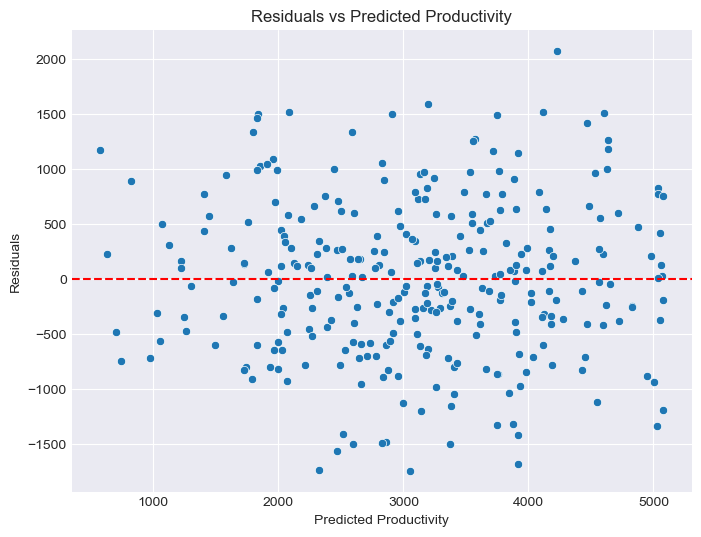

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Step 1: Load the dataset
df = pd.read_csv('Employee_productivity.csv')

# Step 2: Inspect the columns to ensure we have the correct data
print("Columns in the dataset:", df.columns)
print(df.head())

# Step 3: Visualize the relationships between each feature and productivity

# Scatter plots to visualize the relationships
plt.figure(figsize=(12, 8))

# Plot Years at Company vs Productivity
plt.subplot(2, 2, 1)
sns.scatterplot(x='YearsAtCompany', y='ProductivityScore', data=df)
plt.title('Years at Company vs Productivity')

# Plot Hours Worked vs Productivity
plt.subplot(2, 2, 2)
sns.scatterplot(x='HoursWorked', y='ProductivityScore', data=df)
plt.title('Hours Worked vs Productivity')

# Plot Focus vs Productivity
plt.subplot(2, 2, 3)
sns.scatterplot(x='FocusScore', y='ProductivityScore', data=df)
plt.title('Focus vs Productivity')

# Plot Meetings per Week vs Productivity
plt.subplot(2, 2, 4)
sns.scatterplot(x='TeamMeetingsPerWeek', y='ProductivityScore', data=df)
plt.title('Meetings per Week vs Productivity')

plt.tight_layout()
plt.show()

# Step 4: Calculate correlation coefficients for each feature and productivity
correlations = df[['YearsAtCompany', 'HoursWorked', 'FocusScore', 'TeamMeetingsPerWeek', 'ProductivityScore']].corr()
print("Correlation with ProductivityScore:")
print(correlations['ProductivityScore'])

# Step 5: Calculate R-squared for each feature with respect to ProductivityScore

def calculate_r_squared(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model.score(X, y)

# R-squared for Years at Company
X_years = df[['YearsAtCompany']]
r_squared_years = calculate_r_squared(X_years, df['ProductivityScore'])

# R-squared for Hours Worked
X_hours = df[['HoursWorked']]
r_squared_hours = calculate_r_squared(X_hours, df['ProductivityScore'])

# R-squared for Focus Score
X_focus = df[['FocusScore']]
r_squared_focus = calculate_r_squared(X_focus, df['ProductivityScore'])

# R-squared for Meetings per Week
X_meetings = df[['TeamMeetingsPerWeek']]
r_squared_meetings = calculate_r_squared(X_meetings, df['ProductivityScore'])

# Print R-squared values
print(f'R-squared for Years at Company: {r_squared_years}')
print(f'R-squared for Hours Worked: {r_squared_hours}')
print(f'R-squared for Focus Score: {r_squared_focus}')
print(f'R-squared for Meetings per Week: {r_squared_meetings}')

# Step 6: Build a Multiple Linear Regression Model using all features

# Define features and target variable
X = df[['YearsAtCompany', 'HoursWorked', 'FocusScore', 'TeamMeetingsPerWeek']]
y = df['ProductivityScore']

# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Get the R-squared value for the full model
r_squared_full = model.score(X, y)
print(f'R-squared for Full Model: {r_squared_full}')

# Get the coefficients of each feature
coefficients = model.coef_
features = X.columns

print('Model Coefficients:')
for feature, coef in zip(features, coefficients):
    print(f'{feature}: {coef}')

# Step 7: Visualize the residuals (differences between actual and predicted productivity)
y_pred = model.predict(X)
residuals = y - y_pred

# Plot residuals to check model fit
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Productivity')
plt.xlabel('Predicted Productivity')
plt.ylabel('Residuals')
plt.show()



1. Scatter Plots for Feature vs Productivity

Years at Company vs Productivity: There’s a very weak relationship between YearsAtCompany and ProductivityScore (almost no trend, indicating a low correlation).

Hours Worked vs Productivity: There is a slight relationship but no clear pattern indicating that hours worked do not directly correlate strongly with productivity.

Focus vs Productivity: This shows a strong positive relationship, with higher focus scores correlating with higher productivity. This is a key factor for boosting productivity.

Meetings per Week vs Productivity: There seems to be no strong relationship, suggesting that meetings don't have a consistent effect on productivity in this data.

2. Correlation and R-squared Values

Correlation Values:

YearsAtCompany has a very weak negative correlation with productivity.

HoursWorked shows a slightly negative correlation with productivity, suggesting that more hours worked might not necessarily equate to better productivity.

FocusScore has a very strong positive correlation with productivity, confirming the importance of focus.

TeamMeetingsPerWeek shows a very weak negative correlation with productivity.

R-squared Values:

FocusScore has the highest R-squared value, suggesting it's the strongest predictor for productivity.

HoursWorked and TeamMeetingsPerWeek show much lower R-squared values, indicating weaker contributions to predicting productivity.

The model's overall R-squared value is 0.678, which means about 68% of the variation in productivity can be explained by the combined features.

3. Model Coefficients

YearsAtCompany: Positive coefficient, meaning that as employees stay longer, their productivity may increase slightly, but the effect is minimal.

HoursWorked: Negative coefficient, suggesting that increasing hours worked actually decreases productivity slightly.

FocusScore: Positive and significant, indicating that better focus leads to higher productivity.

TeamMeetingsPerWeek: Positive but small coefficient, indicating that more meetings slightly increase productivity (although this effect is not strong).

4. Residuals vs Predicted Productivity

The residuals plot appears randomly distributed around zero with no clear patterns, indicating that the model fits the data well and there aren't unaccounted patterns.

Summary & Recommendations:

Focus is the strongest factor influencing productivity. To boost productivity, a key recommendation would be to improve the work environment to reduce distractions, enhance focus, or offer strategies like time-blocking for deep work.

Meetings: While meetings don't seem to have a strong relationship with productivity in this data, reducing unnecessary meetings might still help improve overall efficiency.

Work Hours: Rather than increasing work hours, the company might focus on improving the quality of work and providing better support to employees to optimize their time during working hours.

Employee Tenure: Although YearsAtCompany has a weak impact, helping newer employees integrate quickly into the company might enhance their productivity, especially through mentorship programs.